# Test Parquet Data Files
This notebook tests the parquet files created by fetch_market_data.py

In [9]:
import pandas as pd
import os
from pathlib import Path
import json

## Check Available Files

In [10]:
# List all parquet files in data directory
data_dir = Path('data')
minute_dir = data_dir / 'minute'

print("Daily Data Files:")
daily_files = list(data_dir.glob('*.parquet'))
for f in sorted(daily_files):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")

print("\nMinute Data Files:")
if minute_dir.exists():
    minute_files = list(minute_dir.glob('*.parquet'))
    for f in sorted(minute_files)[:10]:  # Show first 10
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name} ({size_kb:.1f} KB)")
    if len(minute_files) > 10:
        print(f"  ... and {len(minute_files) - 10} more files")
else:
    print("  No minute data directory found")

print("\nSummary JSON Files:")
json_files = list(data_dir.glob('*.json'))
for f in sorted(json_files):
    print(f"  {f.name}")

Daily Data Files:
  iwm_2025.parquet (20.4 KB)
  qqq_2025.parquet (20.4 KB)
  spx_2025.parquet (19.8 KB)
  spy_2025.parquet (20.4 KB)

Minute Data Files:
  iwm_minute_20250825.parquet (100.9 KB)
  iwm_minute_20250826.parquet (100.4 KB)
  iwm_minute_20250827.parquet (100.6 KB)
  iwm_minute_20250828.parquet (99.4 KB)
  iwm_minute_20250829.parquet (100.5 KB)
  qqq_minute_20250825.parquet (102.8 KB)
  qqq_minute_20250826.parquet (102.6 KB)
  qqq_minute_20250827.parquet (103.0 KB)
  qqq_minute_20250828.parquet (103.3 KB)
  qqq_minute_20250829.parquet (103.0 KB)
  ... and 10 more files

Summary JSON Files:
  iwm_summary.json
  qqq_summary.json
  spx_summary.json
  spy_summary.json


## Test Daily Data

In [11]:
# Test reading a daily data file
ticker = 'spy'  # Change this to test different tickers: iwm, spy, qqq, spx
daily_file = data_dir / f"{ticker}_2025.parquet"

if daily_file.exists():
    df_daily = pd.read_parquet(daily_file)
    
    print(f"=== {ticker.upper()} Daily Data ===")
    print(f"Shape: {df_daily.shape}")
    print(f"Date Range: {df_daily.index.min()} to {df_daily.index.max()}")
    print(f"\nColumns ({len(df_daily.columns)}):")
    print(list(df_daily.columns))
    
    print("\nFirst 3 rows:")
    display(df_daily.head(3))
    
    print("\nLast 3 rows:")
    display(df_daily.tail(3))
    
    # Check for expected columns
    expected_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    missing = [col for col in expected_cols if col not in df_daily.columns]
    if missing:
        print(f"\n⚠️ WARNING: Missing expected columns: {missing}")
    else:
        print(f"\n✅ All expected OHLCV columns present")
    
    # Check for indicators
    indicator_cols = ['rsi_14', 'ma_20', 'ema_9', 'atr_14', 'rvol']
    found_indicators = [col for col in indicator_cols if col in df_daily.columns]
    if found_indicators:
        print(f"✅ Found indicators: {found_indicators}")
    
else:
    print(f"File not found: {daily_file}")

=== SPY Daily Data ===
Shape: (5, 35)
Date Range: 2025-08-25 00:00:00 to 2025-08-29 00:00:00

Columns (35):
['Open', 'High', 'Low', 'Close', 'Volume', 'ticker', 'ticker_symbol', 'fetch_timestamp', 'data_source', 'ma_5', 'ma_10', 'ma_20', 'ma_50', 'volume_ma_10', 'volume_ma_20', 'return', 'daily_return', 'volatility_5d', 'volatility_20d', 'ema_9', 'ema_21', 'ema_50', 'rsi_14', 'rsi_9', 'rvol', 'rvol_10', 'stoch_rsi_k', 'stoch_rsi_d', 'obv', 'atr_14', 'atr_20', 'volume_usd', 'high_low_spread', 'high_low_spread_pct', 'intraday_return']

First 3 rows:


Price,Open,High,Low,Close,Volume,ticker,ticker_symbol,fetch_timestamp,data_source,ma_5,...,rvol_10,stoch_rsi_k,stoch_rsi_d,obv,atr_14,atr_20,volume_usd,high_low_spread,high_low_spread_pct,intraday_return
2025-08-25,644.039978,645.289978,642.349976,642.489990,45194217,SPY,SPY,2025-09-01 02:51:29.138512,minute_aggregation,NaN,...,45194217.0,NaN,NaN,45194217.0,2.940002,2.940002,2.903683e+10,2.940002,0.457695,-0.240666
2025-08-26,642.200012,645.510010,641.570007,645.130005,44557704,SPY,SPY,2025-09-01 02:51:29.138512,minute_aggregation,NaN,...,44557704.0,NaN,NaN,89751921.0,3.073336,3.035241,2.874551e+10,3.940002,0.614119,0.456243
2025-08-27,644.570007,647.369995,644.419983,646.599976,39821159,SPY,SPY,2025-09-01 02:51:29.138512,minute_aggregation,NaN,...,39821159.0,NaN,NaN,129573080.0,3.056893,3.027124,2.574836e+10,2.950012,0.457778,0.314934



Last 3 rows:


Price,Open,High,Low,Close,Volume,ticker,ticker_symbol,fetch_timestamp,data_source,ma_5,...,rvol_10,stoch_rsi_k,stoch_rsi_d,obv,atr_14,atr_20,volume_usd,high_low_spread,high_low_spread_pct,intraday_return
2025-08-27,644.570007,647.369995,644.419983,646.599976,39821159,SPY,SPY,2025-09-01 02:51:29.138512,minute_aggregation,NaN,...,39821159.0,NaN,NaN,129573080.0,3.056893,3.027124,2.574836e+10,2.950012,0.457778,0.314934
2025-08-28,647.239990,649.479980,645.340027,648.859985,54371990,SPY,SPY,2025-09-01 02:51:29.138512,minute_aggregation,NaN,...,54371990.0,NaN,NaN,183945070.0,3.201301,3.133107,3.527981e+10,4.139954,0.641515,0.250293
2025-08-29,647.469971,647.840027,643.140015,644.989990,62936818,SPY,SPY,2025-09-01 02:51:29.138512,minute_aggregation,645.613989,...,62936818.0,NaN,NaN,121008252.0,3.537123,3.379475,4.059362e+10,4.700012,0.730791,-0.383026



✅ All expected OHLCV columns present
✅ Found indicators: ['rsi_14', 'ma_20', 'ema_9', 'atr_14', 'rvol']


## Test Minute Data

In [12]:
# Test reading a minute data file
ticker = 'spy'  # Change this to test different tickers
date = '20250829'  # Change this to test different dates

minute_file = minute_dir / f"{ticker}_minute_{date}.parquet"

if minute_file.exists():
    df_minute = pd.read_parquet(minute_file)
    
    print(f"=== {ticker.upper()} Minute Data for {date} ===")
    print(f"Shape: {df_minute.shape}")
    print(f"Time Range: {df_minute.index.min()} to {df_minute.index.max()}")
    
    # Check columns
    print(f"\nColumns: {list(df_minute.columns)}")
    print(f"Column types: {type(df_minute.columns).__name__}")
    
    # Check for MultiIndex columns (which would be a problem)
    if isinstance(df_minute.columns, pd.MultiIndex):
        print("\n⚠️ WARNING: MultiIndex columns detected!")
        print(f"Level 0: {list(df_minute.columns.get_level_values(0).unique())}")
        print(f"Level 1: {list(df_minute.columns.get_level_values(1).unique())}")
    else:
        print("✅ Single-level columns (correct)")
    
    print("\nFirst 5 rows:")
    display(df_minute.head())
    
    print("\nLast 5 rows:")
    display(df_minute.tail())
    
    # Statistics
    print("\nDaily Statistics from Minute Data:")
    if 'Open' in df_minute.columns:
        print(f"  Open: ${df_minute['Open'].iloc[0]:.2f}")
    if 'High' in df_minute.columns:
        print(f"  High: ${df_minute['High'].max():.2f}")
    if 'Low' in df_minute.columns:
        print(f"  Low: ${df_minute['Low'].min():.2f}")
    if 'Close' in df_minute.columns:
        print(f"  Close: ${df_minute['Close'].iloc[-1]:.2f}")
    if 'Volume' in df_minute.columns:
        print(f"  Total Volume: {df_minute['Volume'].sum():,.0f}")
        print(f"  Avg Volume/min: {df_minute['Volume'].mean():,.0f}")
else:
    print(f"File not found: {minute_file}")
    print("\nAvailable minute files:")
    if minute_dir.exists():
        for f in sorted(minute_dir.glob(f"{ticker}_minute_*.parquet"))[:5]:
            print(f"  {f.name}")

=== SPY Minute Data for 20250829 ===
Shape: (390, 31)
Time Range: 2025-08-29 13:30:00+00:00 to 2025-08-29 19:59:00+00:00

Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'ma_5', 'ma_10', 'ma_20', 'ma_50', 'ma_390', 'volume_ma_10', 'volume_ma_20', 'return', 'volatility_30min', 'volatility_day', 'ema_9', 'ema_21', 'ema_50', 'rsi_14', 'rsi_30', 'rvol', 'rvol_10', 'stoch_rsi_k', 'stoch_rsi_d', 'obv', 'atr_14', 'atr_20', 'volume_usd', 'high_low_spread', 'high_low_spread_pct', 'intraday_return']
Column types: Index
✅ Single-level columns (correct)

First 5 rows:


Price,Open,High,Low,Close,Volume,ma_5,ma_10,ma_20,ma_50,ma_390,...,rvol_10,stoch_rsi_k,stoch_rsi_d,obv,atr_14,atr_20,volume_usd,high_low_spread,high_low_spread_pct,intraday_return
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-08-29 13:30:00+00:00,647.469971,647.840027,647.349976,647.510010,0,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,0.0,0.490051,0.490051,0.000000e+00,0.490051,0.075701,0.006184
2025-08-29 13:31:00+00:00,647.500000,647.758118,647.405029,647.690002,346517,NaN,NaN,NaN,NaN,NaN,...,346517.0,NaN,NaN,346517.0,0.471790,0.477007,2.244356e+08,0.353088,0.054539,0.029344
2025-08-29 13:32:00+00:00,647.695007,647.739990,647.489990,647.515015,294232,NaN,NaN,NaN,NaN,NaN,...,294232.0,NaN,NaN,52285.0,0.442218,0.455387,1.905196e+08,0.250000,0.038611,-0.027790
2025-08-29 13:33:00+00:00,647.510010,647.539978,647.340027,647.469421,245133,NaN,NaN,NaN,NaN,NaN,...,245133.0,NaN,NaN,-192848.0,0.409915,0.431060,1.587161e+08,0.199951,0.030888,-0.006268
2025-08-29 13:34:00+00:00,647.460022,647.500000,647.284973,647.409973,200227,647.518884,NaN,NaN,NaN,NaN,...,200227.0,NaN,NaN,-393075.0,0.383930,0.410486,1.296290e+08,0.215027,0.033220,-0.007730



Last 5 rows:


Price,Open,High,Low,Close,Volume,ma_5,ma_10,ma_20,ma_50,ma_390,...,rvol_10,stoch_rsi_k,stoch_rsi_d,obv,atr_14,atr_20,volume_usd,high_low_spread,high_low_spread_pct,intraday_return
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-08-29 19:55:00+00:00,643.859985,644.184998,643.760010,644.080017,704041,644.062000,644.371002,644.450247,644.579054,NaN,...,1.246871,2.922451,12.178090,-3509740.0,0.322129,0.294157,4.534587e+08,0.424988,0.066016,0.034174
2025-08-29 19:56:00+00:00,644.080017,644.260010,644.049988,644.224976,680827,644.102991,644.310498,644.450497,644.569552,NaN,...,1.145901,3.561865,6.385657,-2828913.0,0.307181,0.286144,4.386058e+08,0.210022,0.032610,0.022506
2025-08-29 19:57:00+00:00,644.229980,644.780029,644.229980,644.645020,1168044,644.172998,644.262000,644.467249,644.568252,NaN,...,1.739106,13.550967,6.678428,-1660869.0,0.340231,0.311755,7.529737e+08,0.550049,0.085381,0.064424
2025-08-29 19:58:00+00:00,644.645020,644.809998,644.440002,644.734985,1545822,644.310999,644.257495,644.485999,644.566952,NaN,...,1.986675,24.928291,14.013708,-115047.0,0.344200,0.317301,9.966455e+08,0.369995,0.057413,0.013956
2025-08-29 19:59:00+00:00,644.734985,645.039978,644.119995,644.989990,3419248,644.534998,644.295496,644.513748,644.573052,644.559142,...,3.201761,40.600498,26.359919,3304201.0,0.420971,0.374700,2.205381e+09,0.919983,0.142828,0.039552



Daily Statistics from Minute Data:
  Open: $647.47
  High: $647.84
  Low: $643.14
  Close: $644.99
  Total Volume: 62,936,818
  Avg Volume/min: 161,376


## Test Summary JSON

In [13]:
# Test reading summary JSON
ticker = 'spy'  # Change this to test different tickers
summary_file = data_dir / f"{ticker}_summary.json"

if summary_file.exists():
    with open(summary_file, 'r') as f:
        summary = json.load(f)
    
    print(f"=== {ticker.upper()} Summary ===")
    for key, value in summary.items():
        if isinstance(value, float):
            if 'return' in key.lower() or 'pct' in key.lower():
                print(f"{key}: {value:.2f}%")
            elif 'volume' in key.lower():
                print(f"{key}: {value:,.0f}")
            else:
                print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")
else:
    print(f"Summary file not found: {summary_file}")

=== SPY Summary ===
ticker: SPY
ticker_symbol: SPY
last_update: 2025-09-01T02:51:29.161281
last_date: 2025-08-29 00:00:00
first_date: 2025-08-25 00:00:00
total_daily_records: 5
minute_data_available_from: 2025-08-25
current_year_file: spy_2025.parquet
latest_close: 644.9900
latest_volume: 62936818
latest_rsi_14: None
latest_rvol: 62936818.0000
latest_stoch_rsi_k: None
latest_stoch_rsi_d: None
latest_obv: 121008252.0000
latest_atr_14: 3.5371
data_source: 1-minute aggregation
ytd_return: 0.39%


## Validate Data Integrity

In [14]:
# Comprehensive data validation
def validate_ticker_data(ticker):
    issues = []
    
    # Check daily data
    daily_file = data_dir / f"{ticker}_2025.parquet"
    if not daily_file.exists():
        issues.append(f"Missing daily data file: {daily_file.name}")
    else:
        df = pd.read_parquet(daily_file)
        
        # Check required columns
        required = ['Open', 'High', 'Low', 'Close', 'Volume']
        missing = [col for col in required if col not in df.columns]
        if missing:
            issues.append(f"Daily data missing columns: {missing}")
        
        # Check for nulls in OHLCV
        for col in ['Open', 'High', 'Low', 'Close']:
            if col in df.columns and df[col].isna().any():
                issues.append(f"Daily data has NaN values in {col}")
        
        # Check data consistency
        if 'High' in df.columns and 'Low' in df.columns:
            invalid = df[df['High'] < df['Low']]
            if not invalid.empty:
                issues.append(f"Daily data has {len(invalid)} rows where High < Low")
    
    # Check minute data
    minute_files = list(minute_dir.glob(f"{ticker}_minute_*.parquet")) if minute_dir.exists() else []
    if not minute_files:
        issues.append(f"No minute data files found for {ticker}")
    else:
        # Check a sample minute file
        sample_file = minute_files[0]
        df_min = pd.read_parquet(sample_file)
        
        if isinstance(df_min.columns, pd.MultiIndex):
            issues.append(f"Minute data has MultiIndex columns (should be flattened)")
        
        missing = [col for col in required if col not in df_min.columns]
        if missing:
            issues.append(f"Minute data missing columns: {missing}")
    
    # Check summary
    summary_file = data_dir / f"{ticker}_summary.json"
    if not summary_file.exists():
        issues.append(f"Missing summary file: {summary_file.name}")
    
    return issues

# Validate all tickers
print("=== Data Validation Report ===")
for ticker in ['iwm', 'spy', 'qqq', 'spx']:
    issues = validate_ticker_data(ticker)
    if issues:
        print(f"\n❌ {ticker.upper()}: {len(issues)} issues found")
        for issue in issues:
            print(f"   - {issue}")
    else:
        print(f"\n✅ {ticker.upper()}: All checks passed")

=== Data Validation Report ===

✅ IWM: All checks passed

✅ SPY: All checks passed

✅ QQQ: All checks passed

✅ SPX: All checks passed


## Quick Data Visualization

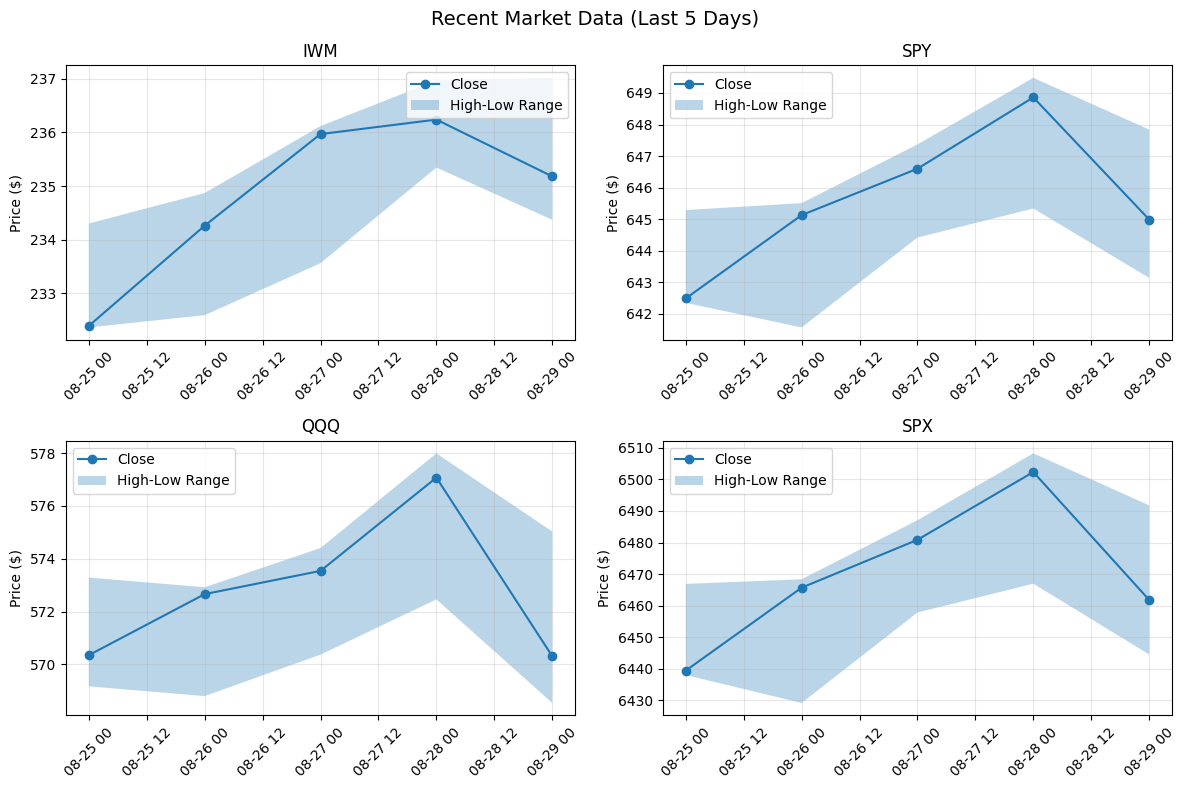

In [15]:
import matplotlib.pyplot as plt

# Plot recent price data for all tickers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Recent Market Data (Last 5 Days)', fontsize=14)

tickers = ['iwm', 'spy', 'qqq', 'spx']
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    daily_file = data_dir / f"{ticker}_2025.parquet"
    
    if daily_file.exists():
        df = pd.read_parquet(daily_file)
        
        # Plot last 5 days
        recent = df.tail(5)
        
        if 'Close' in recent.columns:
            ax.plot(recent.index, recent['Close'], marker='o', label='Close')
            ax.fill_between(recent.index, recent['Low'], recent['High'], alpha=0.3, label='High-Low Range')
            
            ax.set_title(f"{ticker.upper()}")
            ax.set_ylabel('Price ($)')
            ax.grid(True, alpha=0.3)
            ax.legend()
            
            # Format x-axis
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, f'No price data for {ticker.upper()}', 
                   ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, f'No data file for {ticker.upper()}', 
               ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Compare Daily Aggregated vs Minute Data

In [16]:
# Compare daily OHLCV calculated from minute data vs stored daily data
ticker = 'spy'
test_date = '2025-08-29'

# Load daily data
daily_file = data_dir / f"{ticker}_2025.parquet"
if daily_file.exists():
    df_daily = pd.read_parquet(daily_file)
    
    # Get the row for test_date
    if test_date in df_daily.index.strftime('%Y-%m-%d'):
        daily_row = df_daily[df_daily.index.strftime('%Y-%m-%d') == test_date].iloc[0]
        
        print(f"=== {ticker.upper()} Daily Data for {test_date} ===")
        print(f"Open:  ${daily_row['Open']:.2f}")
        print(f"High:  ${daily_row['High']:.2f}")
        print(f"Low:   ${daily_row['Low']:.2f}")
        print(f"Close: ${daily_row['Close']:.2f}")
        print(f"Volume: {daily_row['Volume']:,.0f}")

# Load minute data for same date
minute_file = minute_dir / f"{ticker}_minute_{test_date.replace('-', '')}.parquet"
if minute_file.exists():
    df_minute = pd.read_parquet(minute_file)
    
    print(f"\n=== Calculated from Minute Data ===")
    if all(col in df_minute.columns for col in ['Open', 'High', 'Low', 'Close', 'Volume']):
        print(f"Open:  ${df_minute['Open'].iloc[0]:.2f} (first minute)")
        print(f"High:  ${df_minute['High'].max():.2f} (max of all minutes)")
        print(f"Low:   ${df_minute['Low'].min():.2f} (min of all minutes)")
        print(f"Close: ${df_minute['Close'].iloc[-1]:.2f} (last minute)")
        print(f"Volume: {df_minute['Volume'].sum():,.0f} (sum of all minutes)")
        
        print(f"\nMinute bars in file: {len(df_minute)}")
        print(f"Expected (6.5 hours * 60): 390")
    else:
        print("Missing required columns in minute data")
else:
    print(f"\nMinute file not found: {minute_file.name}")

=== SPY Daily Data for 2025-08-29 ===
Open:  $647.47
High:  $647.84
Low:   $643.14
Close: $644.99
Volume: 62,936,818

=== Calculated from Minute Data ===
Open:  $647.47 (first minute)
High:  $647.84 (max of all minutes)
Low:   $643.14 (min of all minutes)
Close: $644.99 (last minute)
Volume: 62,936,818 (sum of all minutes)

Minute bars in file: 390
Expected (6.5 hours * 60): 390
